# 預處理：建立虛擬環境並加入環境

In [1]:
import os
import sys
import subprocess
from pathlib import Path
import shutil
from typing import Optional

# ==========================================
# 設定區
# ==========================================
# 如果您想指定特定版本的 Python (例如 3.10)，請在此填入 python.exe 的完整路徑
# 例如: TARGET_PYTHON_PATH = r"C:\Python310\python.exe"
# 如果設為 None，將使用當前執行此腳本的 Python 版本
TARGET_PYTHON_PATH: Optional[str] = None 
# ==========================================

def get_python_exec() -> str:
    """決定要使用哪個 Python 執行檔來建立環境"""
    if TARGET_PYTHON_PATH and os.path.exists(TARGET_PYTHON_PATH):
        return TARGET_PYTHON_PATH
    
    # 如果沒有指定，使用當前的 sys.executable
    return sys.executable

def check_python_version(python_path: str) -> str:
    """檢查並顯示選定 Python 的版本"""
    try:
        result = subprocess.run(
            [python_path, "--version"], 
            capture_output=True, 
            text=True, 
            check=True
        )
        return result.stdout.strip()
    except Exception:
        return "Unknown Version"

def run_command(command: str, description: str) -> None:
    """執行指令並即時顯示輸出，避免看起來像卡死"""
    print(f"⏳ [{description}]...")
    
    try:
        # 修改：強制指定 encoding='utf-8' 並忽略錯誤 (errors='replace')
        # 這能解決 Windows CP950 與 pip 輸出編碼不一致導致的崩潰
        process = subprocess.Popen(
            command,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
            shell=True if os.name == 'nt' else False,
            encoding='utf-8',       # 強制 UTF-8
            errors='replace'        # 遇到無法解碼的字符用 ? 取代，防止報錯
        )

        while True:
            if process.stdout is None:
                break
            output = process.stdout.readline()
            if output == '' and process.poll() is not None:
                break
            if output:
                print(f"  | {output.strip()}")
        
        rc = process.poll()
        if rc is not None and rc != 0:
            if process.stderr is not None:
                err = process.stderr.read()
                print(f"❌ [{description}] 失敗！錯誤訊息：\n{err}")
            raise subprocess.CalledProcessError(rc, command)
            
        print(f"✅ [{description}] 完成。\n")
        
    except Exception as e:
        print(f"執行時發生錯誤: {e}")
        raise e

def setup_project_env() -> None:
    venv_name = "Project"
    base_path = Path.cwd()
    venv_path = base_path / venv_name
    
    # 決定來源 Python (用來創建環境的母體)
    source_python = get_python_exec()
    source_version = check_python_version(source_python)
    
    # 決定目標 Python (虛擬環境內的 Python)
    venv_python = str(venv_path / "Scripts" / "python.exe")

    print(f"=== 🚀 開始設定虛擬環境: {venv_name} ===")
    print(f"工作目錄: {base_path}")
    print(f"來源 Python: {source_python}")
    print(f"版本資訊: {source_version}")
    print("-" * 40)

    # 1. 檢查並創建虛擬環境
    if not venv_path.exists():
        # 使用 source_python 來執行 -m venv，這樣就會創建該版本的環境
        cmd_str = f'"{source_python}" -m venv "{venv_name}"'
        run_command(cmd_str, f"創建虛擬環境 (基於 {source_version})")
    else:
        print(f"✅ [1/4] 虛擬環境 '{venv_name}' 已存在，跳過創建。")
        # 檢查已存在的環境版本是否與預期相符
        if os.path.exists(venv_python):
            existing_ver = check_python_version(venv_python)
            print(f"      (現有環境版本: {existing_ver})")
        print("\n")

    if not os.path.exists(venv_python):
        print(f"❌ 嚴重錯誤：找不到 {venv_python}")
        print("請嘗試刪除 Project 資料夾後重試。")
        return

    # 2. 升級 pip
    pip_cmd = f'"{venv_python}" -m pip install --upgrade pip --no-warn-script-location'
    run_command(pip_cmd, "2/4 升級 pip")

    # 3. 安裝 ipykernel
    kernel_cmd = f'"{venv_python}" -m pip install ipykernel --no-warn-script-location'
    run_command(kernel_cmd, "3/4 安裝 ipykernel")

    # 4. 註冊 Kernel
    display_name = f"Python ({venv_name})"
    register_cmd = f'"{venv_python}" -m ipykernel install --user --name {venv_name} --display-name "{display_name}"'
    run_command(register_cmd, "4/4 註冊 Jupyter Kernel")

    print("="*60)
    print("🎉 設定全部完成！")
    print(f"建立的版本: {source_version}")
    print(f"現在請依照以下步驟啟用環境：")
    print(f"1. 點擊 VS Code 右上角的 'Select Kernel'")
    print(f"2. 選擇 '{display_name}'")
    print(f"3. 或是使用魔術指令安裝套件： %pip install -r requirements.txt")
    print("="*60)

if __name__ == "__main__":
    setup_project_env()

=== 🚀 開始設定虛擬環境: Project ===
工作目錄: c:\Clark\YZU\Papper\Code
來源 Python: c:\Clark\YZU\Papper\Code\Project\Scripts\python.exe
版本資訊: Python 3.11.9
----------------------------------------
✅ [1/4] 虛擬環境 'Project' 已存在，跳過創建。
      (現有環境版本: Python 3.11.9)


⏳ [2/4 升級 pip]...
  | Requirement already satisfied: pip in .\Project\Lib\site-packages (26.0.1)
✅ [2/4 升級 pip] 完成。

⏳ [3/4 安裝 ipykernel]...
  | Requirement already satisfied: ipykernel in .\Project\Lib\site-packages (6.29.5)
  | Requirement already satisfied: comm>=0.1.1 in .\Project\Lib\site-packages (from ipykernel) (0.2.3)
  | Requirement already satisfied: debugpy>=1.6.5 in .\Project\Lib\site-packages (from ipykernel) (1.8.20)
  | Requirement already satisfied: ipython>=7.23.1 in .\Project\Lib\site-packages (from ipykernel) (9.9.0)
  | Requirement already satisfied: jupyter-client>=6.1.12 in .\Project\Lib\site-packages (from ipykernel) (7.4.9)
  | Requirement already satisfied: jupyter-core!=5.0.*,>=4.12 in .\Project\Lib\site-packages (f

# 預處理：安裝需要的各個套件

In [ ]:
%pip install -r requirements.txt

# 第零階段：基礎配對

[資料載入] 發現本地緩存 data\sp500_data_2015-01-01_2021-01-01.pkl，正在讀取...
[資料載入] 緩存讀取成功。數據矩陣形狀: (1511, 491)
[系統資訊] 共生成 9 個滾動回測窗口。
處理窗口 1/9: 2016-01-04 到 2016-07-05 00:00:00 ...
處理窗口 2/9: 2016-07-05 到 2017-01-03 00:00:00 ...
處理窗口 3/9: 2017-01-03 到 2017-07-05 00:00:00 ...
處理窗口 4/9: 2017-07-05 到 2018-01-03 00:00:00 ...
處理窗口 5/9: 2018-01-03 到 2018-07-05 00:00:00 ...
處理窗口 6/9: 2018-07-05 到 2019-01-04 00:00:00 ...
處理窗口 7/9: 2019-01-04 到 2019-07-08 00:00:00 ...
處理窗口 8/9: 2019-07-08 到 2020-01-06 00:00:00 ...
處理窗口 9/9: 2020-01-06 到 2020-07-07 00:00:00 ...

[系統資訊] 回測完成，產生報表...


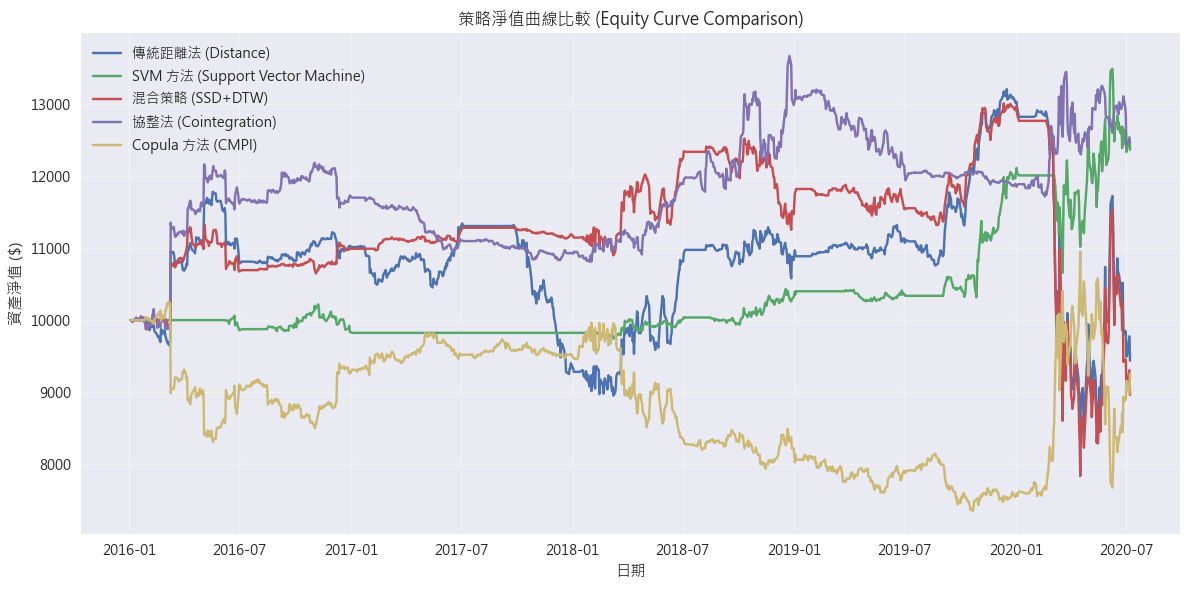


詳細績效指標表


,策略名稱,年化報酬率 (CAGR),夏普率 (Sharpe),索提諾比率 (Sortino),勝率 (Win Rate),最大回撤 (MaxDD),總損益 (PnL)
0,傳統距離法 (Distance),-1.28%,0.05,0.06,50.20%,-37.24%,$-563
1,SVM 方法 (Support Vector Machine),4.82%,0.49,0.45,51.60%,-12.01%,"$2,362"
2,混合策略 (SSD+DTW),-2.41%,-0.00,-0.00,49.84%,-39.76%,"$-1,039"
3,協整法 (Cointegration),5.01%,0.46,0.68,46.79%,-14.27%,"$2,466"
4,Copula 方法 (CMPI),-1.70%,0.01,0.01,51.29%,-29.92%,$-744



配對詳細紀錄 (Pair Records)


,Window_Start_Date,Strategy_Name,Stock_A,Stock_B,Metric_Name,Metric_Score,Hedge_Ratio
0,2016-01-04,傳統距離法 (Distance),AMCR,LIN,SSD,0.356375,1.0
1,2016-01-04,傳統距離法 (Distance),AMCR,BRK-B,SSD,0.411856,1.0
2,2016-01-04,傳統距離法 (Distance),AMCR,GWW,SSD,0.423672,1.0
3,2016-01-04,傳統距離法 (Distance),AMCR,NUE,SSD,0.448065,1.0
4,2016-01-04,傳統距離法 (Distance),ALL,AMCR,SSD,0.722369,1.0
5,2016-01-04,傳統距離法 (Distance),AMCR,OXY,SSD,0.756451,1.0
6,2016-01-04,傳統距離法 (Distance),AMCR,JCI,SSD,0.770965,1.0
7,2016-01-04,傳統距離法 (Distance),AMCR,LNT,SSD,0.796599,1.0
8,2016-01-04,傳統距離法 (Distance),AMCR,XYL,SSD,0.806672,1.0
9,2016-01-04,傳統距離法 (Distance),AMCR,J,SSD,0.826986,1.0


[系統資訊] 總共紀錄 852 個配對。
[系統資訊] 配對紀錄已匯出至 data\pair_records.csv


In [4]:
# -*- coding: utf-8 -*-
from abc import ABC, abstractmethod
from typing import Dict, List, Tuple, Optional, Union, Any
from datetime import datetime
import datetime as dt
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
from scipy import stats
from sklearn.svm import OneClassSVM
import matplotlib.pyplot as plt
from itertools import combinations
import warnings
import traceback
import requests
import io
import os
import json

# ============ 環境配置 ============
try:
    from IPython.display import display as display_func
except ImportError:
    def display_func(x: Any) -> None:
        print(x)

warnings.filterwarnings("ignore")

try:
    plt.style.use('seaborn-v0_8')
except:
    plt.style.use('ggplot')

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Microsoft JhengHei', 'SimHei', 'WenQuanYi Micro Hei', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = 'data'
if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)
    print(f"[系統資訊] 已建立資料儲存目錄: {DATA_DIR}")

# ==========================================
# 0. 工具函數與類別 (優化版本)
# ==========================================

def get_sp500_tickers(filename: str = 'sp500_tickers.json') -> List[str]:
    """從 Wikipedia 獲取 S&P 500 成分股列表並進行本地緩存。"""
    cache_file = os.path.join(DATA_DIR, filename)

    if os.path.exists(cache_file):
        try:
            with open(cache_file, 'r') as f:
                tickers = json.load(f)
            return tickers
        except Exception:
            pass

    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    headers = {'User-Agent': 'Mozilla/5.0'}
    try:
        response = requests.get(url, headers=headers, timeout=10)
        tables = pd.read_html(io.StringIO(response.text))
        df = tables[0]
        tickers = df['Symbol'].tolist()
        clean_tickers = [ticker.replace('.', '-') for ticker in tickers]
        
        with open(cache_file, 'w') as f:
            json.dump(clean_tickers, f)
        print(f"[系統資訊] 成功獲取 {len(clean_tickers)} 檔股票代碼並儲存至 {cache_file}。")
        return clean_tickers
    except Exception as e:
        print(f"[錯誤] 獲取 S&P 500 列表失敗: {e}")
        return []

class DistanceUtils:
    """距離計算工具箱，包含 DTW 邏輯。"""
    @staticmethod
    def calculate_dtw(series_a: np.ndarray, series_b: np.ndarray) -> float:
        """計算動態時間規畫距離。"""
        try:
            from dtaidistance import dtw
            return float(dtw.distance(series_a.astype(np.float64), series_b.astype(np.float64)))
        except ImportError:
            return DistanceUtils._dtw_numpy(series_a, series_b)

    @staticmethod
    def _dtw_numpy(s1: np.ndarray, s2: np.ndarray) -> float:
        """原生 NumPy DTW 實作。"""
        r, c = len(s1), len(s2)
        D0 = np.zeros((r + 1, c + 1))
        D0[0, 1:] = np.inf
        D0[1:, 0] = np.inf
        D = D0[1:, 1:]
        
        dist_matrix = (s1[:, None] - s2[None, :]) ** 2
        
        for i in range(r):
            for j in range(c):
                cost = dist_matrix[i, j]
                D[i, j] = cost + min(D0[i, j], D0[i+1, j], D0[i, j+1])
        
        return float(np.sqrt(D[r-1, c-1]))

# ==========================================
# 1. 數據處理模組 (優化版本)
# ==========================================

class DataHandler:
    """數據下載、緩存與視窗生成。"""
    def __init__(self, tickers: List[str], start_date: str, end_date: str) -> None:
        self.tickers = tickers
        self.start_date = start_date
        self.end_date = end_date
        self.cache_file = os.path.join(DATA_DIR, f'sp500_data_{start_date}_{end_date}.pkl')
        self.data: Optional[pd.DataFrame] = None

    def fetch_data(self) -> pd.DataFrame:
        """下載或讀取歷史股價數據 (Adj Close)。"""
        if os.path.exists(self.cache_file):
            print(f"[資料載入] 發現本地緩存 {self.cache_file}，正在讀取...")
            try:
                cached_data = pd.read_pickle(self.cache_file)
                if not cached_data.empty:
                    self.data = cached_data
                    print(f"[資料載入] 緩存讀取成功。數據矩陣形狀: {self.data.shape}")
                    return self.data
            except Exception as e:
                print(f"[資料載入] 緩存讀取失敗 ({e})，準備重新下載...")

        print(f"[資料下載] 開始下載數據 ({self.start_date} 到 {self.end_date})，共 {len(self.tickers)} 檔...")
        try:
            full_data = yf.download(self.tickers, start=self.start_date, end=self.end_date, progress=True, auto_adjust=False)
            
            if full_data is None or full_data.empty:
                return pd.DataFrame()

            if isinstance(full_data.columns, pd.MultiIndex):
                if 'Adj Close' in full_data.columns.get_level_values(0):
                    raw_data: Union[pd.Series, pd.DataFrame] = full_data['Adj Close']
                elif 'Close' in full_data.columns.get_level_values(0):
                    raw_data = full_data['Close']
                else:
                    raw_data = full_data
            else:
                if 'Adj Close' in full_data.columns:
                    raw_data = full_data['Adj Close']
                elif 'Close' in full_data.columns:
                    raw_data = full_data['Close']
                else:
                    raw_data = full_data

            # 確保 raw_data 是 DataFrame
            if isinstance(raw_data, pd.Series):
                raw_data = raw_data.to_frame()
            
            self.data = raw_data.ffill().bfill()
            threshold = len(self.data) * 0.9
            self.data = self.data.dropna(axis=1, thresh=int(threshold))
            
            self.data.to_pickle(self.cache_file)
            print(f"[資料下載] 下載完成並已緩存至 {self.cache_file}。有效股票: {self.data.shape[1]}")
            return self.data
            
        except Exception as e:
            print(f"[錯誤] 數據下載失敗: {e}")
            traceback.print_exc()
            return pd.DataFrame()

    @staticmethod
    def get_rolling_windows(data: pd.DataFrame, formation_days: int = 252, 
                           trading_days: int = 126) -> List[Dict[str, Any]]:
        """生成滾動回測視窗。"""
        n = len(data)
        indices: List[Dict[str, Any]] = []
        step = trading_days
        
        if n < formation_days + trading_days:
            return []

        for start_idx in range(0, n - formation_days - trading_days, step):
            form_start = start_idx
            form_end = start_idx + formation_days
            trade_start = form_end
            trade_end = form_end + trading_days
            
            indices.append({
                'form_start': data.index[form_start],
                'form_end': data.index[form_end],
                'trade_start': data.index[trade_start],
                'trade_end': data.index[trade_end]
            })
        return indices

# ==========================================
# 2. 抽象基底類別 (Abstract Base Class)
# ==========================================

class Strategy(ABC):
    """
    策略抽象基底類別。
    所有策略必須實現 train() 與 get_signals() 方法。
    """
    def __init__(self, name: str, num_pairs: int = 20) -> None:
        self.name = name
        self.num_pairs = num_pairs
        self.pairs: List[Dict[str, Any]] = []

    @abstractmethod
    def train(self, formation_data: pd.DataFrame) -> None:
        """在形成期訓練模型，選出配對。"""
        raise NotImplementedError

    @abstractmethod
    def get_signals(self, trading_data: pd.DataFrame) -> pd.Series:
        """
        在交易期執行交易，計算損益。
        使用向量化操作，返回日損益序列。
        """
        raise NotImplementedError

    def _calculate_ssd(self, price_df: pd.DataFrame, top_n_filter: int = 500) -> List[Tuple[str, str, float]]:
        """計算標準化價格平方差和 (SSD) - 向量化版本。"""
        norm_prices = price_df / price_df.iloc[0]
        returns = price_df.pct_change().fillna(0)
        
        valid_cols = returns.columns[returns.std() > 1e-6]
        returns = returns[valid_cols]
        norm_prices = norm_prices[valid_cols]
        
        corr_matrix = returns.corr().fillna(-1)
        corr_pairs = (corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
                      .stack()
                      .sort_values(ascending=True)
                      .head(top_n_filter))
        
        candidates: List[Tuple[str, str, float]] = []
        for (s1, s2), _ in corr_pairs.items():
            ssd = float(((norm_prices[s1] - norm_prices[s2]) ** 2).sum())
            candidates.append((s1, s2, ssd))
            
        candidates.sort(key=lambda x: x[2])
        return candidates

# ==========================================
# 3. 距離法策略 - 向量化版本
# ==========================================

class DistanceStrategy(Strategy):
    """傳統距離法 (Distance Method) - 向量化實作。"""
    def __init__(self, num_pairs: int = 20, entry_sigma: float = 2.0, 
                 exit_sigma: float = 0.0, transaction_cost_bps: float = 10.0) -> None:
        super().__init__("傳統距離法 (Distance)", num_pairs)
        self.entry_sigma = entry_sigma
        self.exit_sigma = exit_sigma
        self.transaction_cost_bps = transaction_cost_bps

    def train(self, formation_data: pd.DataFrame) -> None:
        """在形成期選出 SSD 最小的前 N 對。"""
        ranked_pairs = self._calculate_ssd(formation_data)
        top_pairs = ranked_pairs[:self.num_pairs]
        
        self.pairs = []
        norm_data = formation_data / formation_data.iloc[0]
        
        for s1, s2, ssd in top_pairs:
            spread = norm_data[s1] - norm_data[s2]
            std_dev = float(spread.std())
            self.pairs.append({
                's1': s1, 's2': s2, 'std': std_dev, 'ssd': ssd,
                'metric_value': ssd, 'metric_name': 'SSD'
            })

    def get_signals(self, trading_data: pd.DataFrame) -> pd.Series:
        """
        向量化交易邏輯。
        使用 shift() 與遮罩操作替代逐日迴圈。
        """
        daily_rets = pd.Series(0.0, index=trading_data.index)
        cost_multiplier = self.transaction_cost_bps / 10000.0
        
        norm_trade_data = trading_data / trading_data.iloc[0]
        returns = trading_data.pct_change().fillna(0)
        
        for pair in self.pairs:
            s1, s2 = pair['s1'], pair['s2']
            if s1 not in norm_trade_data.columns or s2 not in norm_trade_data.columns:
                continue

            spread = norm_trade_data[s1] - norm_trade_data[s2]
            threshold = self.entry_sigma * pair['std']
            
            # 向量化訊號生成
            long_signal = spread < -threshold  # 做多價差
            short_signal = spread > threshold  # 做空價差
            exit_signal = np.abs(spread) <= self.exit_sigma * pair['std']
            
            # 狀態轉移 (向量化)
            position = np.zeros(len(spread))
            for i in range(len(spread)):
                if i == 0:
                    continue
                if position[i-1] == 0:
                    if long_signal.iloc[i]:
                        position[i] = 1
                    elif short_signal.iloc[i]:
                        position[i] = -1
                else:
                    if exit_signal.iloc[i]:
                        position[i] = 0
                    else:
                        position[i] = position[i-1]
            
            # 計算損益 (向量化)
            position_series = pd.Series(position, index=spread.index)
            position_shift = position_series.shift(1).fillna(0)
            position_change = position_shift.diff().fillna(0)
            
            # 價格變化收益
            price_pnl = position_shift * (returns[s1] - returns[s2])
            
            # 交易成本
            trade_cost = np.abs(position_change) * cost_multiplier
            
            daily_rets += (price_pnl - trade_cost) / self.num_pairs
        
        return daily_rets

# ==========================================
# 3B. SVM 策略 - 向量化版本
# ==========================================

class SVMStrategy(Strategy):
    """
    SVM 配對選擇策略 (Support Vector Machine Method) - 向量化實作。
    使用 One-Class SVM 識別高質量配對，交易邏輯同傳統距離法。
    """
    def __init__(self, num_pairs: int = 20, entry_sigma: float = 2.0, 
                 exit_sigma: float = 0.0, transaction_cost_bps: float = 10.0,
                 svm_nu: float = 0.05) -> None:
        super().__init__("SVM 方法 (Support Vector Machine)", num_pairs)
        self.entry_sigma = entry_sigma
        self.exit_sigma = exit_sigma
        self.transaction_cost_bps = transaction_cost_bps
        self.svm_nu = svm_nu  # One-Class SVM 異常比例參數

    def _extract_pair_features(self, price_df: pd.DataFrame, s1: str, s2: str) -> np.ndarray:
        """
        提取配對特徵向量 (用於SVM訓練)。
        特徵包括：價格比、波動率比、相關係數、價差統計等。
        """
        p1 = price_df[s1].values
        p2 = price_df[s2].values
        
        # 歸一化
        p1_norm = p1 / p1[0]
        p2_norm = p2 / p2[0]
        
        # 計算特徵
        spread = p1_norm - p2_norm
        
        features = np.array([
            float(np.corrcoef(p1, p2)[0, 1]),           # 相關係數
            float(np.std(spread)),                        # 價差標準差
            float(np.mean(np.abs(spread))),              # 平均絕對價差
            float(np.std(np.diff(p1_norm)) / np.std(np.diff(p2_norm)) + 1e-6),  # 波動率比
            float(np.var(spread)),                        # 價差方差
            float(np.max(spread) - np.min(spread)),      # 價差範圍
        ])
        
        return features

    def train(self, formation_data: pd.DataFrame) -> None:
        """
        使用 One-Class SVM 選出高質量配對。
        步驟：
        1. 計算所有配對的特徵向量
        2. 使用 One-Class SVM 識別"好的"配對
        3. 根據 SVM 決策函數值排序
        4. 選擇評分最高的 N 對配對
        """
        ranked_pairs = self._calculate_ssd(formation_data, top_n_filter=200)
        
        if len(ranked_pairs) < self.num_pairs:
            print(f"[警告] 候選配對數 ({len(ranked_pairs)}) 少於所需配對數 ({self.num_pairs})")
        
        # 提取所有候選配對的特徵
        features_list: List[np.ndarray] = []
        valid_pairs: List[Tuple[str, str, float]] = []
        
        for s1, s2, ssd in ranked_pairs:
            try:
                features = self._extract_pair_features(formation_data, s1, s2)
                features_list.append(features)
                valid_pairs.append((s1, s2, ssd))
            except Exception:
                continue
        
        if len(features_list) < 5:
            print("[警告] 有效特徵不足，降級使用 SSD 方法")
            self.pairs = []
            norm_data = formation_data / formation_data.iloc[0]
            
            for s1, s2, ssd in ranked_pairs[:self.num_pairs]:
                spread = norm_data[s1] - norm_data[s2]
                std_dev = float(spread.std())
                self.pairs.append({
                    's1': s1, 's2': s2, 'std': std_dev, 'ssd': ssd,
                    'metric_value': ssd, 'metric_name': 'SSD'
                })
            return
        
        # 訓練 One-Class SVM
        X = np.array(features_list)
        svm_model = OneClassSVM(kernel='rbf', gamma='auto', nu=self.svm_nu)
        svm_model.fit(X)
        
        # 獲取 SVM 決策函數值 (越高越好)
        svm_scores = svm_model.decision_function(X)
        
        # 根據 SVM 得分排序
        sorted_indices = np.argsort(-svm_scores)  # 降序排列
        
        # 選擇評分最高的 N 對配對
        self.pairs = []
        norm_data = formation_data / formation_data.iloc[0]
        
        for idx in sorted_indices[:self.num_pairs]:
            s1, s2, ssd = valid_pairs[idx]
            spread = norm_data[s1] - norm_data[s2]
            std_dev = float(spread.std())
            svm_score = float(svm_scores[idx])
            
            self.pairs.append({
                's1': s1, 's2': s2, 'std': std_dev, 'ssd': ssd,
                'metric_value': svm_score, 'metric_name': 'SVM_Score'
            })

    def get_signals(self, trading_data: pd.DataFrame) -> pd.Series:
        """
        交易邏輯與傳統距離法相同 (向量化實作)。
        """
        daily_rets = pd.Series(0.0, index=trading_data.index)
        cost_multiplier = self.transaction_cost_bps / 10000.0
        
        norm_trade_data = trading_data / trading_data.iloc[0]
        returns = trading_data.pct_change().fillna(0)
        
        for pair in self.pairs:
            s1, s2 = pair['s1'], pair['s2']
            if s1 not in norm_trade_data.columns or s2 not in norm_trade_data.columns:
                continue

            spread = norm_trade_data[s1] - norm_trade_data[s2]
            threshold = self.entry_sigma * pair['std']
            
            # 向量化訊號生成
            long_signal = spread < -threshold
            short_signal = spread > threshold
            exit_signal = np.abs(spread) <= self.exit_sigma * pair['std']
            
            # 狀態轉移
            position = np.zeros(len(spread))
            for i in range(len(spread)):
                if i == 0:
                    continue
                if position[i-1] == 0:
                    if long_signal.iloc[i]:
                        position[i] = 1
                    elif short_signal.iloc[i]:
                        position[i] = -1
                else:
                    if exit_signal.iloc[i]:
                        position[i] = 0
                    else:
                        position[i] = position[i-1]
            
            # 計算損益
            position_series = pd.Series(position, index=spread.index)
            position_shift = position_series.shift(1).fillna(0)
            position_change = position_shift.diff().fillna(0)
            
            price_pnl = position_shift * (returns[s1] - returns[s2])
            trade_cost = np.abs(position_change) * cost_multiplier
            
            daily_rets += (price_pnl - trade_cost) / self.num_pairs
        
        return daily_rets

# ==========================================
# 4. 混合策略 (Hybrid SSD+DTW) - 向量化版本
# ==========================================

class HybridStrategy(Strategy):
    """混合策略 (SSD+DTW) - 向量化實作。"""
    def __init__(self, num_pairs: int = 20, entry_sigma: float = 2.0, 
                 exit_sigma: float = 0.0, transaction_cost_bps: float = 10.0) -> None:
        super().__init__("混合策略 (SSD+DTW)", num_pairs)
        self.entry_sigma = entry_sigma
        self.exit_sigma = exit_sigma
        self.transaction_cost_bps = transaction_cost_bps
    
    def train(self, formation_data: pd.DataFrame) -> None:
        """使用雙重排名機制選出配對。"""
        candidates = self._calculate_ssd(formation_data, top_n_filter=200)
        
        norm_data = formation_data / formation_data.iloc[0]
        hybrid_candidates: List[Dict[str, Any]] = []
        
        for s1, s2, ssd in candidates:
            series_a = np.asarray(norm_data[s1].values, dtype=np.float64)
            series_b = np.asarray(norm_data[s2].values, dtype=np.float64)
            dtw_val = DistanceUtils.calculate_dtw(series_a, series_b)
            
            hybrid_candidates.append({
                's1': s1, 's2': s2, 
                'ssd': ssd, 'dtw': dtw_val
            })
            
        df_res = pd.DataFrame(hybrid_candidates)
        if df_res.empty: return

        # 向量化排名
        df_res['rank_ssd'] = df_res['ssd'].rank(ascending=True)
        df_res['rank_dtw'] = df_res['dtw'].rank(ascending=True)
        df_res['combined_score'] = df_res['rank_ssd'] + df_res['rank_dtw']
        
        top_pairs_df = df_res.sort_values('combined_score').head(self.num_pairs)
        
        self.pairs = []
        for _, row in top_pairs_df.iterrows():
            s1, s2 = row['s1'], row['s2']
            spread = norm_data[s1] - norm_data[s2]
            std_dev = float(spread.std())
            self.pairs.append({
                's1': s1, 's2': s2, 'std': std_dev,
                'metric_value': float(row['combined_score']), 'metric_name': 'Combined_Score'
            })

    def get_signals(self, trading_data: pd.DataFrame) -> pd.Series:
        """交易邏輯同 Distance Strategy (使用標準差回歸)。"""
        daily_rets = pd.Series(0.0, index=trading_data.index)
        cost_multiplier = self.transaction_cost_bps / 10000.0
        
        norm_trade_data = trading_data / trading_data.iloc[0]
        returns = trading_data.pct_change().fillna(0)
        
        for pair in self.pairs:
            s1, s2 = pair['s1'], pair['s2']
            if s1 not in norm_trade_data.columns or s2 not in norm_trade_data.columns:
                continue

            spread = norm_trade_data[s1] - norm_trade_data[s2]
            threshold = self.entry_sigma * pair['std']
            
            long_signal = spread < -threshold
            short_signal = spread > threshold
            exit_signal = np.abs(spread) <= self.exit_sigma * pair['std']
            
            position = np.zeros(len(spread))
            for i in range(1, len(spread)):
                if position[i-1] == 0:
                    if long_signal.iloc[i]:
                        position[i] = 1
                    elif short_signal.iloc[i]:
                        position[i] = -1
                else:
                    if exit_signal.iloc[i]:
                        position[i] = 0
                    else:
                        position[i] = position[i-1]
            
            position_series = pd.Series(position, index=spread.index)
            position_shift = position_series.shift(1).fillna(0)
            position_change = position_shift.diff().fillna(0)
            
            price_pnl = position_shift * (returns[s1] - returns[s2])
            trade_cost = np.abs(position_change) * cost_multiplier
            
            daily_rets += (price_pnl - trade_cost) / self.num_pairs
        
        return daily_rets

# ==========================================
# 5. 協整法策略 - 向量化版本
# ==========================================

class CointegrationStrategy(Strategy):
    """協整法 (Cointegration) - 向量化實作。"""
    def __init__(self, num_pairs: int = 20, entry_z: float = 2.0, 
                 exit_z: float = 0.0, transaction_cost_bps: float = 10.0) -> None:
        super().__init__("協整法 (Cointegration)", num_pairs)
        self.entry_z = entry_z
        self.exit_z = exit_z
        self.transaction_cost_bps = transaction_cost_bps

    def train(self, formation_data: pd.DataFrame) -> None:
        """依序檢定協整關係 (Engle-Granger Test)。"""
        ranked_pairs = self._calculate_ssd(formation_data)
        self.pairs = []
        formation_data = formation_data.clip(lower=0.01)
        log_prices = np.log(formation_data)
        
        for s1, s2, ssd in ranked_pairs:
            if len(self.pairs) >= self.num_pairs: break
            if float(log_prices[s1].std()) < 1e-4 or float(log_prices[s2].std()) < 1e-4: continue

            try:
                score, pvalue, _ = coint(log_prices[s1], log_prices[s2])
            except: continue
            
            if pvalue < 0.05:
                Y = log_prices[s1]
                X = sm.add_constant(log_prices[s2])
                model = sm.OLS(Y, X).fit()
                
                alpha = float(model.params.iloc[0])
                beta = float(model.params.iloc[1])
                
                residuals = Y - (alpha + beta * log_prices[s2])
                self.pairs.append({
                    's1': s1, 's2': s2, 'beta': beta, 'alpha': alpha,
                    'mu': float(residuals.mean()), 'sigma': float(residuals.std()), 'pvalue': float(pvalue),
                    'metric_value': float(pvalue), 'metric_name': 'P-value'
                })

    def get_signals(self, trading_data: pd.DataFrame) -> pd.Series:
        """基於協整殘差 Z-Score 的向量化交易。"""
        daily_rets = pd.Series(0.0, index=trading_data.index)
        cost_multiplier = self.transaction_cost_bps / 10000.0
        trading_data = trading_data.clip(lower=0.01)
        log_trade = np.log(trading_data)
        returns = trading_data.pct_change().fillna(0)
        
        for pair in self.pairs:
            s1, s2 = pair['s1'], pair['s2']
            if s1 not in log_trade.columns or s2 not in log_trade.columns: continue

            beta = pair['beta']
            alpha = pair['alpha']
            mu = pair['mu']
            sigma = pair['sigma']
            residuals = log_trade[s1] - beta * log_trade[s2] - alpha
            z_scores = (residuals - mu) / sigma
            
            long_signal = z_scores < -self.entry_z
            short_signal = z_scores > self.entry_z
            exit_signal = np.abs(z_scores) <= self.exit_z
            
            position = np.zeros(len(z_scores))
            for i in range(1, len(z_scores)):
                if position[i-1] == 0:
                    if long_signal.iloc[i]:
                        position[i] = 1
                    elif short_signal.iloc[i]:
                        position[i] = -1
                else:
                    if exit_signal.iloc[i]:
                        position[i] = 0
                    else:
                        position[i] = position[i-1]
            
            position_series = pd.Series(position, index=z_scores.index)
            position_shift = position_series.shift(1).fillna(0)
            position_change = position_shift.diff().fillna(0)
            
            # 對沖損益 (考量 Beta)
            price_pnl = position_shift * (returns[s1] - beta * returns[s2])
            trade_cost = np.abs(position_change) * (1 + abs(beta)) * cost_multiplier
            
            daily_rets += (price_pnl - trade_cost) / self.num_pairs
        
        return daily_rets

# ==========================================
# 6. Copula 法策略 - 向量化版本
# ==========================================

class CopulaStrategy(Strategy):
    """Copula 方法 (CMPI) - 向量化實作。"""
    def __init__(self, num_pairs: int = 20, open_threshold: float = 0.5,
                 transaction_cost_bps: float = 10.0) -> None:
        super().__init__("Copula 方法 (CMPI)", num_pairs)
        self.open_threshold = open_threshold
        self.transaction_cost_bps = transaction_cost_bps
        
    def train(self, formation_data: pd.DataFrame) -> None:
        """基於 Gaussian Copula 參數的配對選擇。"""
        ranked_pairs = self._calculate_ssd(formation_data)
        top_pairs = ranked_pairs[:self.num_pairs]
        returns = formation_data.pct_change().dropna()
        self.pairs = []
        
        for s1, s2, ssd in top_pairs:
            r1 = np.asarray(returns[s1].values, dtype=np.float64)
            r2 = np.asarray(returns[s2].values, dtype=np.float64)
            
            sorted_r1 = np.sort(r1)
            sorted_r2 = np.sort(r2)
            u = stats.rankdata(r1) / (len(r1) + 1)
            v = stats.rankdata(r2) / (len(r2) + 1)
            
            x = stats.norm.ppf(u)
            y = stats.norm.ppf(v)
            if np.std(x) == 0 or np.std(y) == 0: continue

            rho = float(np.corrcoef(x, y)[0, 1])
            if np.isnan(rho): rho = 0.0
            self.pairs.append({
                's1': s1, 's2': s2, 'rho': rho,
                'sorted_r1': sorted_r1, 'sorted_r2': sorted_r2,
                'metric_value': rho, 'metric_name': 'Rho'
            })

    def _get_conditional_prob_vectorized(self, u: np.ndarray, v: np.ndarray, rho: float) -> np.ndarray:
        """向量化條件機率計算。"""
        u = np.clip(u, 0.0001, 0.9999)
        v = np.clip(v, 0.0001, 0.9999)
        with np.errstate(divide='ignore', invalid='ignore'):
            numerator = stats.norm.ppf(u) - rho * stats.norm.ppf(v)
            denominator = np.sqrt(1 - rho**2)
            result = stats.norm.cdf(numerator / denominator) if denominator > 0 else np.full_like(u, 0.5)
            result = np.where(np.isfinite(result), result, 0.5)
        return result

    def get_signals(self, trading_data: pd.DataFrame) -> pd.Series:
        """基於累積錯誤定價指數 (CMPI) 的向量化交易。"""
        daily_rets = pd.Series(0.0, index=trading_data.index)
        cost_multiplier = self.transaction_cost_bps / 10000.0
        returns = trading_data.pct_change().fillna(0)
        
        for pair in self.pairs:
            s1, s2 = pair['s1'], pair['s2']
            if s1 not in returns.columns or s2 not in returns.columns: continue

            rho = pair['rho']
            r1_series = np.asarray(returns[s1].values, dtype=np.float64)
            r2_series = np.asarray(returns[s2].values, dtype=np.float64)
            
            u_series = np.searchsorted(pair['sorted_r1'], r1_series) / (len(pair['sorted_r1']) + 1)
            v_series = np.searchsorted(pair['sorted_r2'], r2_series) / (len(pair['sorted_r2']) + 1)
            
            # 向量化 CMPI 計算
            M1_vals = self._get_conditional_prob_vectorized(u_series, v_series, rho) - 0.5
            M2_vals = self._get_conditional_prob_vectorized(v_series, u_series, rho) - 0.5
            
            M1_cumsum = np.cumsum(M1_vals)
            M2_cumsum = np.cumsum(M2_vals)
            
            # 訊號生成
            long_signal = (M1_cumsum > self.open_threshold) & (M2_cumsum < -self.open_threshold)
            short_signal = (M1_cumsum < -self.open_threshold) & (M2_cumsum > self.open_threshold)
            exit_signal = ((M1_cumsum * M2_cumsum <= 0) & (np.abs(M1_cumsum) < 0.2))
            
            position = np.zeros(len(r1_series))
            for i in range(1, len(r1_series)):
                if position[i-1] == 0:
                    if long_signal[i]:
                        position[i] = 1
                    elif short_signal[i]:
                        position[i] = -1
                else:
                    if exit_signal[i]:
                        position[i] = 0
                    else:
                        position[i] = position[i-1]
            
            position_series = pd.Series(position, index=returns.index)
            position_shift = position_series.shift(1).fillna(0)
            position_change = position_shift.diff().fillna(0)
            
            price_pnl = position_shift * (returns[s1] - returns[s2])
            trade_cost = np.abs(position_change) * cost_multiplier
            
            daily_rets += (price_pnl - trade_cost) / self.num_pairs
        
        return daily_rets

# ==========================================
# 7. 配對紀錄器 (PairLogger) - 新增
# ==========================================

class PairLogger:
    """
    詳細配對紀錄機制。
    記錄每個回測視窗選出的所有配對資訊。
    """
    def __init__(self) -> None:
        self.records: List[Dict[str, Any]] = []

    def log_pair(self, window_start: dt.datetime, strategy_name: str, 
                 stock_a: str, stock_b: str, metric_name: str, 
                 metric_value: float, hedge_ratio: float = 1.0) -> None:
        """紀錄單個配對。"""
        self.records.append({
            'Window_Start_Date': window_start,
            'Strategy_Name': strategy_name,
            'Stock_A': stock_a,
            'Stock_B': stock_b,
            'Metric_Name': metric_name,
            'Metric_Score': metric_value,
            'Hedge_Ratio': hedge_ratio
        })

    def to_dataframe(self) -> pd.DataFrame:
        """轉換為 DataFrame。"""
        if not self.records:
            return pd.DataFrame()
        return pd.DataFrame(self.records)

    def to_csv(self, filename: str) -> None:
        """匯出為 CSV。"""
        df = self.to_dataframe()
        if not df.empty:
            df.to_csv(filename, index=False)
            print(f"[系統資訊] 配對紀錄已匯出至 {filename}")

# ==========================================
# 8. 回測執行引擎 (Backtester) - 優化版本
# ==========================================

class Backtester:
    """回測執行引擎 - 支援抽象策略介面與詳細紀錄。"""
    def __init__(self, data_handler: DataHandler, strategies: List[Strategy]) -> None:
        self.data_handler = data_handler
        self.strategies = strategies
        self.results: Dict[str, pd.Series] = {strat.name: pd.Series(dtype=float) for strat in strategies}
        self.pair_logger = PairLogger()

    def run(self) -> None:
        """執行完整回測並記錄配對資訊。"""
        full_data = self.data_handler.fetch_data()
        if full_data is None or full_data.empty: return

        windows = self.data_handler.get_rolling_windows(full_data)
        print(f"[系統資訊] 共生成 {len(windows)} 個滾動回測窗口。")
        
        for i, window in enumerate(windows):
            window_start = window['trade_start']
            if isinstance(window_start, str):
                window_start = pd.Timestamp(window_start)
            print(f"處理窗口 {i+1}/{len(windows)}: {window_start.date()} 到 {window['trade_end']} ...")
            form_data = full_data.loc[window['form_start']:window['form_end']]
            trade_data = full_data.loc[window['trade_start']:window['trade_end']]
            
            if len(trade_data) < 10: continue

            for strategy in self.strategies:
                strategy.train(form_data)
                
                # 記錄配對資訊
                for pair in strategy.pairs:
                    hedge_ratio = pair.get('beta', 1.0)
                    metric_name = pair.get('metric_name', 'Unknown')
                    metric_value = pair.get('metric_value', 0.0)
                    
                    self.pair_logger.log_pair(
                        window_start=window_start if isinstance(window_start, dt.datetime) else pd.Timestamp(window_start).to_pydatetime(),
                        strategy_name=strategy.name,
                        stock_a=pair['s1'],
                        stock_b=pair['s2'],
                        metric_name=metric_name,
                        metric_value=metric_value,
                        hedge_ratio=hedge_ratio
                    )
                
                # 執行交易
                pnl = strategy.get_signals(trade_data)
                self.results[strategy.name] = pd.concat([self.results[strategy.name], pnl])

    def get_pair_records(self) -> pd.DataFrame:
        """獲取配對紀錄 DataFrame。"""
        return self.pair_logger.to_dataframe()

    def export_pairs_to_csv(self, filename: str = 'pair_records.csv') -> None:
        """匯出配對紀錄為 CSV。"""
        self.pair_logger.to_csv(filename)

    def report(self, total_capital: float = 10000) -> pd.DataFrame:
        """
        產生績效報表。
        回傳 DataFrame 供 Jupyter 美觀顯示。
        """
        metrics_list: List[Dict[str, Any]] = []
        
        plt.figure(figsize=(12, 6))
        
        for name, pnl_series in self.results.items():
            pnl_series = pnl_series[~pnl_series.index.duplicated(keep='first')].sort_index().fillna(0)
            if len(pnl_series) == 0: continue
            
            initial_capital = total_capital
            cum_ret = (1 + pnl_series).cumprod()
            final_equity = initial_capital * cum_ret.iloc[-1]
            pnl_dollar = final_equity - initial_capital
            
            days = (pnl_series.index[-1] - pnl_series.index[0]).days
            years = days / 365.25
            cagr = (cum_ret.iloc[-1]) ** (1/years) - 1 if years > 0 else 0
            
            volatility = float(pnl_series.std() * np.sqrt(252))
            sharpe = (pnl_series.mean() * 252) / volatility if volatility > 0 else 0
            
            downside_returns = pnl_series[pnl_series < 0]
            downside_vol = float(downside_returns.std() * np.sqrt(252))
            sortino = (pnl_series.mean() * 252) / downside_vol if downside_vol > 0 else 0
            
            rolling_max = cum_ret.cummax()
            drawdown = (cum_ret - rolling_max) / rolling_max
            max_dd = float(drawdown.min())
            
            win_rate = len(pnl_series[pnl_series > 0]) / len(pnl_series[pnl_series != 0]) if len(pnl_series[pnl_series != 0]) > 0 else 0
            
            metrics_list.append({
                '策略名稱': name,
                '年化報酬率 (CAGR)': f"{cagr:.2%}",
                '夏普率 (Sharpe)': f"{sharpe:.2f}",
                '索提諾比率 (Sortino)': f"{sortino:.2f}",
                '勝率 (Win Rate)': f"{win_rate:.2%}",
                '最大回撤 (MaxDD)': f"{max_dd:.2%}",
                '總損益 (PnL)': f"${pnl_dollar:,.0f}"
            })
            
            equity_curve = initial_capital * cum_ret
            plt.plot(equity_curve.index, equity_curve, label=name)
            
        plt.title('策略淨值曲線比較 (Equity Curve Comparison)')
        plt.xlabel('日期')
        plt.ylabel('資產淨值 ($)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        df_metrics = pd.DataFrame(metrics_list)
        print("\n" + "="*80)
        print("詳細績效指標表")
        print("="*80)
        display_func(df_metrics)
        
        return df_metrics

# ==========================================
# 9. 主程式執行
# ==========================================

if __name__ == "__main__":
    # 獲取成分股列表
    tickers = get_sp500_tickers()
        
    # 設定回測區間
    handler = DataHandler(tickers, '2015-01-01', '2021-01-01')
    
    # 初始化策略 (現在使用統一的抽象介面)
    strategies: List[Strategy] = [
        DistanceStrategy(num_pairs=20, entry_sigma=2.0),
        SVMStrategy(num_pairs=20, entry_sigma=2.0),
        HybridStrategy(num_pairs=20, entry_sigma=2.0),
        CointegrationStrategy(num_pairs=20, entry_z=2.0),
        CopulaStrategy(num_pairs=20, open_threshold=0.5)
    ]
    
    # 執行回測
    backtester = Backtester(handler, strategies)
    backtester.run()
    
    # 產生報表與配對紀錄
    print("\n[系統資訊] 回測完成，產生報表...")
    metrics_df = backtester.report(total_capital=10000)
    
    # 顯示配對紀錄
    print("\n" + "="*80)
    print("配對詳細紀錄 (Pair Records)")
    print("="*80)
    pair_records = backtester.get_pair_records()
    if not pair_records.empty:
        display_func(pair_records.head(20))
        print(f"[系統資訊] 總共紀錄 {len(pair_records)} 個配對。")
        
        # 匯出為 CSV
        csv_filename = os.path.join(DATA_DIR, 'pair_records.csv')
        backtester.export_pairs_to_csv(csv_filename)
    else:
        print("未找到任何配對紀錄。")